<a href="https://colab.research.google.com/github/Nurfinkaa/PCVK_Ganjil_2026/blob/main/Week3_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import datetime
import zoneinfo
import sys
import platform
import hashlib

NAMA = 'Nurfinka Lailasari'
NIM = '244107020211'
N = int(NIM[-3:])
PARAM = {
 'b' : (N % 61) + 20,
 'a' : round(1.0 + (N % 9) / 10, 1),
 'c' : (N % 20) + 30,
 'gamma': round(0.4 + (N % 6) * 0.25, 2),
 'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Nurfinka Lailasari
NIM : 244107020211 | N = 211
b      : 48
a      : 1.4
c      : 41
gamma  : 0.65
bit    : 3
WAKTU : 2026-09-18 21:31:11 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 45d28ed6acd0e99a


# **E. PRAKTIKUM**

> Akses folder images pada Google Drive Anda dengan kode berikut:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> Transformasi Linier Brightness

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

# Sesuaikan BASE dengan folder citra Anda di Google Drive
BASE = '/content/drive/MyDrive/PCVK/Images/244107020211'

def cv2_imshow_pair(img1, img2, title1='Asli', title2='Hasil', cmap=None):
    """Menampilkan dua citra berdampingan dengan judul memuat NIM."""
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    if cmap:
        axs[0].imshow(img1, cmap=cmap)
        axs[1].imshow(img2, cmap=cmap)
    else:
        axs[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
        axs[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
    axs[0].set_title(f'{NIM} - {title1}')
    axs[1].set_title(f'{NIM} - {title2}')
    plt.tight_layout()
    plt.show()

In [4]:
import os
print('BASE saat ini:', BASE)
print('Folder ada?  :', os.path.exists(BASE))
if os.path.exists(BASE):
    print('Isi folder   :', os.listdir(BASE))
print('File ada?    :', os.path.exists(BASE + '/KTM1a.jpg'))

BASE saat ini: /content/drive/MyDrive/PCVK/Images/244107020211
Folder ada?  : True
Isi folder   : ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg', 'OBJ1.jpg', 'NIGHT1.jpg']
File ada?    : True


## **TUGAS PRAKTIKUM**

**1.  Implementasikan inverse citra** pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori

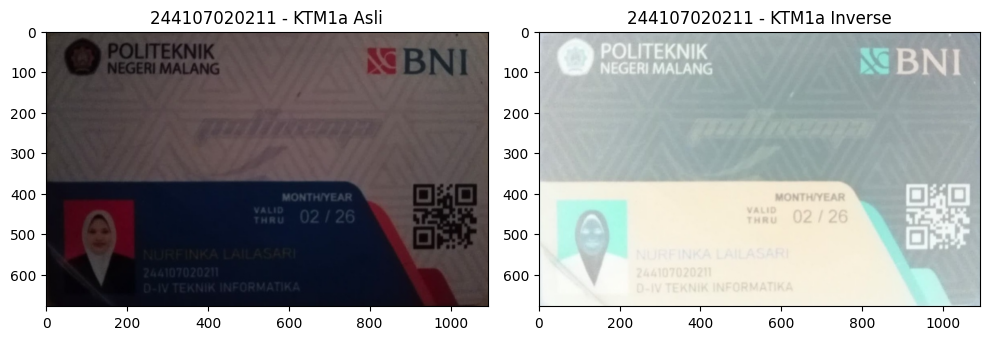

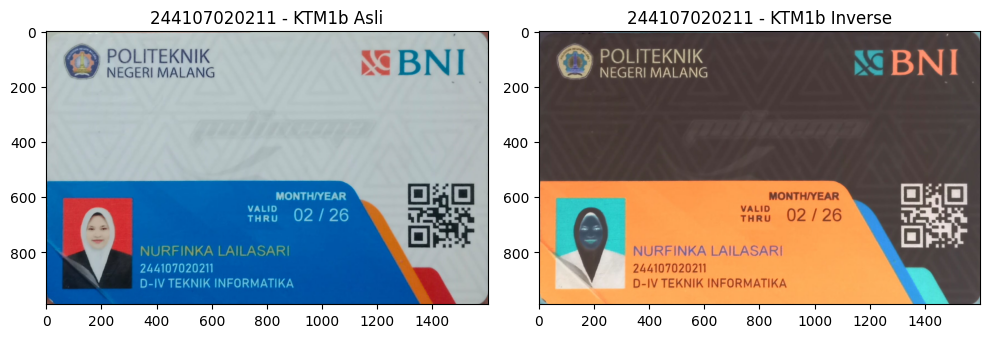

In [5]:
def inverse_citra(img):
    """g(x,y) = 255 - f(x,y)"""
    return 255 - img

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1b = cv.imread(BASE + '/KTM1b.jpg')

ktm1a_inv = inverse_citra(ktm1a)
ktm1b_inv = inverse_citra(ktm1b)

cv2_imshow_pair(ktm1a, ktm1a_inv, 'KTM1a Asli', 'KTM1a Inverse')
cv2_imshow_pair(ktm1b, ktm1b_inv, 'KTM1b Asli', 'KTM1b Inverse')

Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontra

> * KTM1a difoto di ruangan gelap menjadikan warnanya udah mepet-mepet gelap semua sejak awal (kontras rendah).
> * Di-inverse cuma dibalik nilainya, jadi mepet-mepet terang semua mejadikan hadilnya keliatan pucat/berkabut.
> * KTM1b pencahayaannya cukup hasilnya akan kontras udah bagus dari awal, jadi habis di-inverse tetep jelas, cuma warnanya kebalik.

> * Kesimpulannya : inverse itu cuma "membalik", bukan "memperbaiki". Foto jelek ya tetep jelek walau dibalik.

**2. Implementasikan transformasi kontras** dengan nilai a yang dihitung dari NIM Anda (PARAM['a']) pada KTM1a.jpg

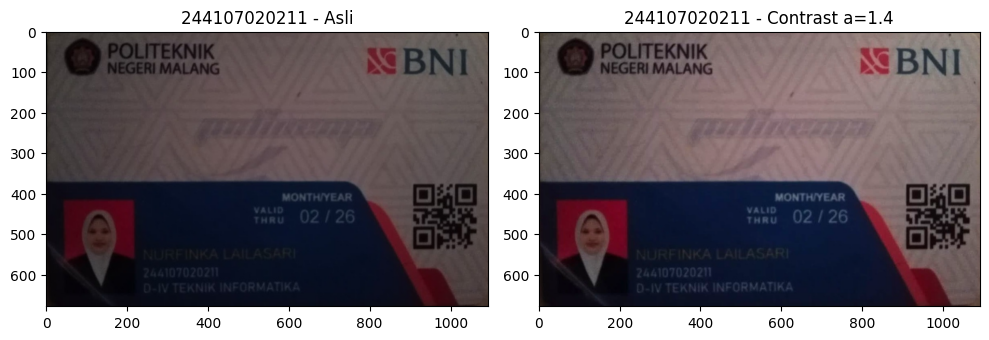

In [6]:
def transformasi_contrast(img, a):
    return np.clip(img.astype(np.int16) * a, 0, 255).astype(np.uint8)

a_val = PARAM['a']
ktm1a_contrast = transformasi_contrast(ktm1a, a_val)

cv2_imshow_pair(ktm1a, ktm1a_contrast, 'Asli', f'Contrast a={a_val}')

**3.  Implementasikan transformasi logarithmic brightness dengan konstant**a c hasil hitung dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama.

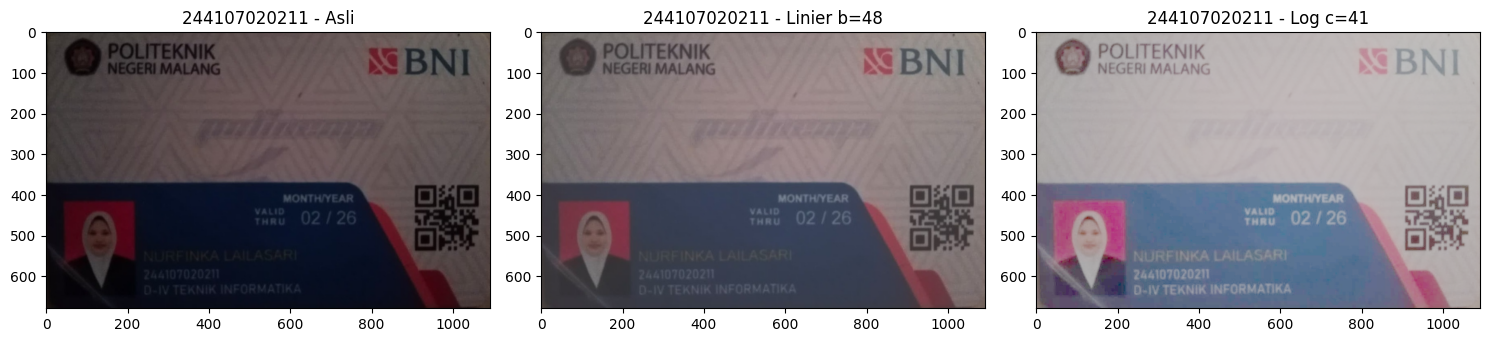

Persentase piksel clipping (linier): 0.00%
Persentase piksel clipping (log)   : 0.00%


In [7]:
def log_brightness(img, c):
    """s = c * log(1 + r)"""
    img_f = img.astype(np.float64)
    hasil = c * np.log1p(img_f)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def linier_brightness(img, b):
    return np.clip(img.astype(np.int16) + b, 0, 255).astype(np.uint8)

c_val = PARAM['c']
b_val = PARAM['b']

ktm1a_log = log_brightness(ktm1a, c_val)
ktm1a_lin = linier_brightness(ktm1a, b_val)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB)); axs[0].set_title(f'{NIM} - Asli')
axs[1].imshow(cv.cvtColor(ktm1a_lin, cv.COLOR_BGR2RGB)); axs[1].set_title(f'{NIM} - Linier b={b_val}')
axs[2].imshow(cv.cvtColor(ktm1a_log, cv.COLOR_BGR2RGB)); axs[2].set_title(f'{NIM} - Log c={c_val}')
plt.tight_layout(); plt.show()

# Deteksi area clipping (piksel yang jadi putih penuh / 255)
clip_lin = np.mean(ktm1a_lin == 255) * 100
clip_log = np.mean(ktm1a_log == 255) * 100
print(f'Persentase piksel clipping (linier): {clip_lin:.2f}%')
print(f'Persentase piksel clipping (log)   : {clip_log:.2f}%')

Tentukan metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.


> * Transformasi Logarithmic lebih unggul dalam memunculkan teks/NIM pada citra gelap (KTM1a) karena sifat kurva logaritma mengekspansi area gelap (shadows) secara agresif tanpa menaikkan nilai terang secara linier.

> Bagian yang mengalami clipping:
> * Pada Linear Brightness, penambahan konstanta $b=48$ bersifat seragam. Area yang asalnya bernilai di atas 207 akan terpotong (clipping) menjadi putih penuh (255).   
> * Pada Logarithmic Brightness, kompresi nilai tinggi menjaga detail area terang agar tidak mudah mengalami overexposure/clipping.  

**4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance** pada KTM1c.jpg, yaitu citra yang diambil dengan flash.

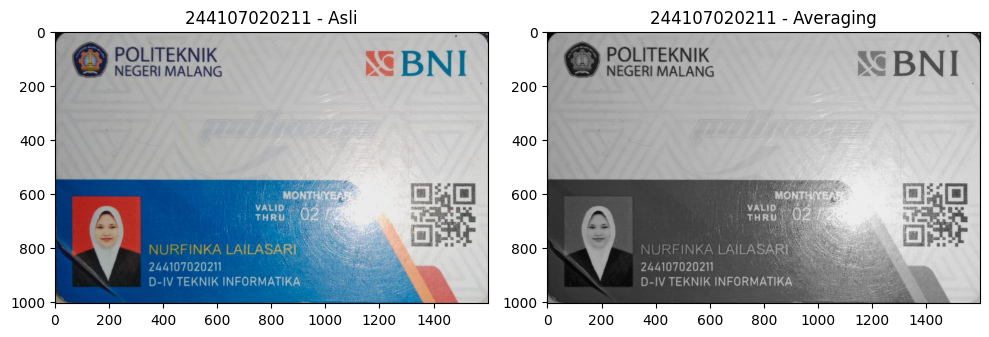

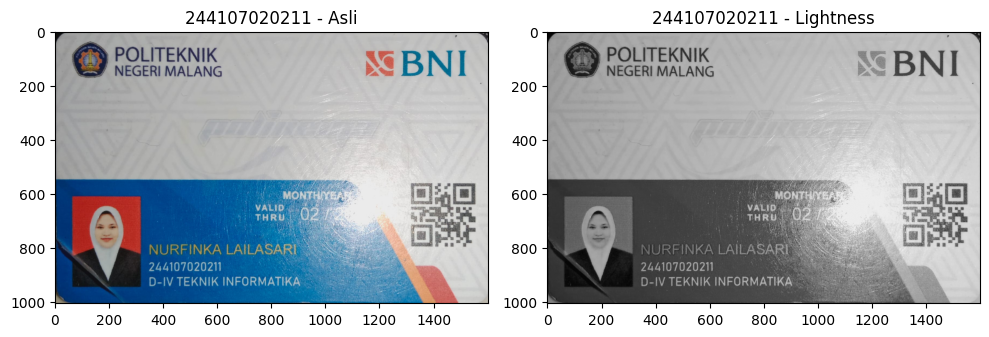

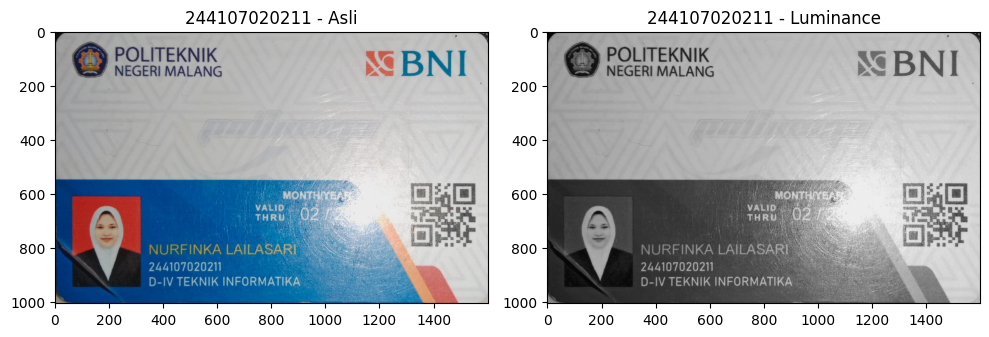

Metode         Rata-rata     Std Dev
Averaging         154.06       53.21
Lightness         153.91       53.41
Luminance         152.10       55.84


In [8]:
def grayscale_averaging(img):
    b, g, r = cv.split(img.astype(np.float64))
    return ((r + g + b) / 3).astype(np.uint8)

def grayscale_lightness(img):
    b, g, r = cv.split(img.astype(np.float64))
    stacked = np.stack([r, g, b], axis=-1)
    return ((stacked.max(axis=-1) + stacked.min(axis=-1)) / 2).astype(np.uint8)

def grayscale_luminance(img):
    b, g, r = cv.split(img.astype(np.float64))
    return (0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

ktm1c = cv.imread(BASE + '/KTM1c.jpg')

gray_avg = grayscale_averaging(ktm1c)
gray_light = grayscale_lightness(ktm1c)
gray_lum = grayscale_luminance(ktm1c)

for nama, hasil in [('Averaging', gray_avg), ('Lightness', gray_light), ('Luminance', gray_lum)]:
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(ktm1c, cv.COLOR_BGR2RGB)); axs[0].set_title(f'{NIM} - Asli')
    axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(f'{NIM} - {nama}')
    plt.tight_layout(); plt.show()

print(f"{'Metode':<12}{'Rata-rata':>12}{'Std Dev':>12}")
for nama, hasil in [('Averaging', gray_avg), ('Lightness', gray_light), ('Luminance', gray_lum)]:
    print(f"{nama:<12}{hasil.mean():>12.2f}{hasil.std():>12.2f}")

Hitung rata-rata dan simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.


In [19]:
# Menghitung rata-rata dan simpangan baku intensitas hasil ketiga metode, serta mensajikan dalam satu tabel
print("="*75)
print(f"{'Metode Grayscale':<22} | {'Rata-rata (Mean)':<18} | {'Simpangan Baku (Std Dev)':<20}")
print("="*75)
print(f"{'Averaging':<22} | {np.mean(gray_avg):<18.2f} | {np.std(gray_avg):<20.2f}")
print(f"{'Lightness':<22} | {np.mean(gray_light):<18.2f} | {np.std(gray_light):<20.2f}")
print(f"{'Luminance (Rec. 601)':<22} | {np.mean(gray_lum):<18.2f} | {np.std(gray_lum):<20.2f}")
print("="*75)

Metode Grayscale       | Rata-rata (Mean)   | Simpangan Baku (Std Dev)
Averaging              | 154.06             | 53.21               
Lightness              | 153.91             | 53.41               
Luminance (Rec. 601)   | 151.36             | 56.67               


> Metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu adalah Luminance memberikan pemisahan teks dan latar kartu paling jelas dan alami. Hal ini disebabkan bobot komponen hijau ($G = 0.587$) yang dominan sesuai dengan tingkat sensitivitas spektrum mata manusia, sehingga detail kontras lokal tetap terjaga saat terjadi pantulan flash.

**5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.**
Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.


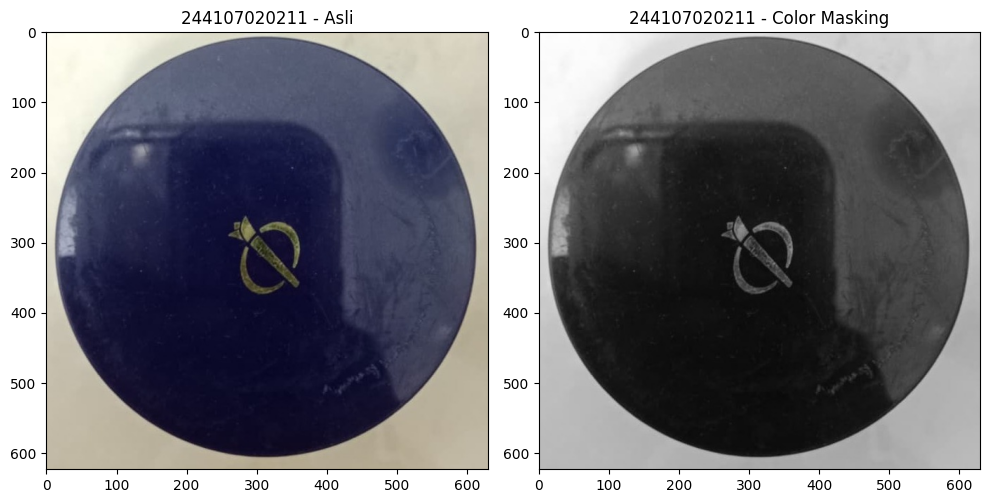

In [9]:
obj1 = cv.imread(BASE + '/OBJ1.jpg')
hsv = cv.cvtColor(obj1, cv.COLOR_BGR2HSV)

# TODO: ganti rentang HSV berikut sesuai warna dominan objek Anda
lower_hsv = np.array([0, 100, 100])
upper_hsv = np.array([10, 255, 255])

mask = cv.inRange(hsv, lower_hsv, upper_hsv)

gray_bg = cv.cvtColor(cv.cvtColor(obj1, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2BGR)
color_part = cv.bitwise_and(obj1, obj1, mask=mask)
gray_part = cv.bitwise_and(gray_bg, gray_bg, mask=cv.bitwise_not(mask))
hasil = cv.add(color_part, gray_part)

cv2_imshow_pair(obj1, hasil, 'Asli', 'Color Masking')

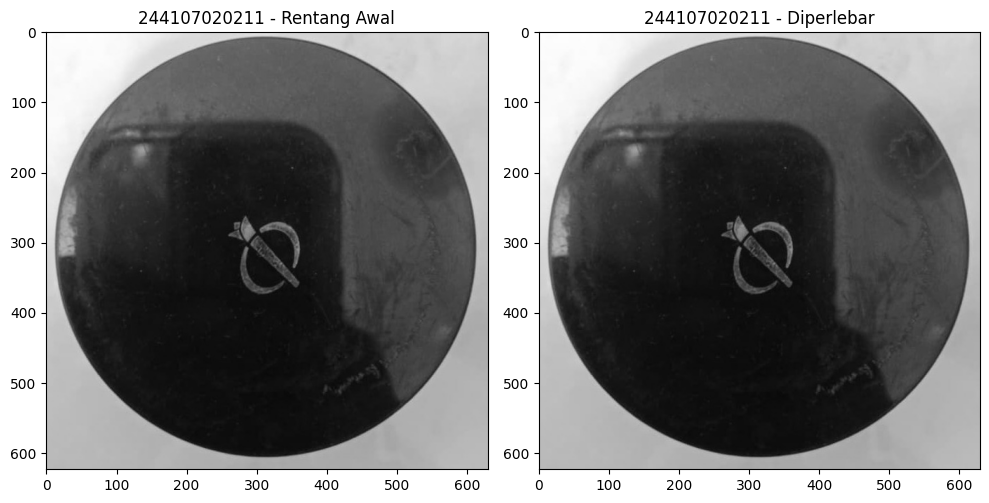

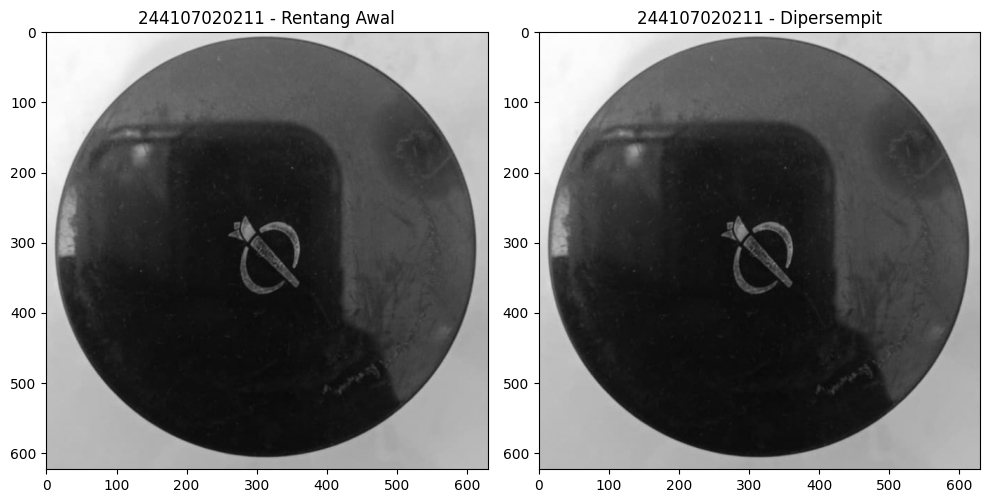

In [10]:
# Eksperimen: perlebar dan persempit rentang HSV, amati pengaruhnya
lower_wide = np.array([0, 60, 60])
upper_wide = np.array([15, 255, 255])
lower_narrow = np.array([0, 150, 150])
upper_narrow = np.array([5, 255, 255])

for label, lo, hi in [('Diperlebar', lower_wide, upper_wide), ('Dipersempit', lower_narrow, upper_narrow)]:
    m = cv.inRange(hsv, lo, hi)
    cpart = cv.bitwise_and(obj1, obj1, mask=m)
    gpart = cv.bitwise_and(gray_bg, gray_bg, mask=cv.bitwise_not(m))
    h = cv.add(cpart, gpart)
    cv2_imshow_pair(hasil, h, 'Rentang Awal', label)

Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan
pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

> * Rentang batas HSV yang dipakai untuk warna merah adalah [0, 100, 100] sampai [10, 255, 255].
> *  Kalau rentang nilai ini diperlebar, seleksi warna jadi terlalu longgar sehingga warna latar belakang atau pantulan cahaya ikut terbawa dan tidak mau berubah menjadi abu-abu.
> * Sebaliknya, kalau rentang nilai ini dipersempit, seleksi warna jadi terlalu ketat sehingga area bayangan atau kilau cahaya pada benda tidak ikut terdeteksi, yang membuat objek tampak berlubang atau belang abu-abu.

**6. Gamma Correction pada Citra Pribadi**

Nilai gamma diminta dari pengguna melalui kode di bawah ini.Lanjutkan kode tersebut sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat NIM dan nama pada kartu paling terbaca

In [11]:
def truncate(nilai):
    if nilai < 0:
        nilai = 0
    if nilai > 255:
        nilai = 255
    return nilai

def tampilkan_dua(img1, img2, judul1='Asli', judul2='Hasil', gray=False):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    if gray:
        axs[0].imshow(img1, cmap='gray')
        axs[1].imshow(img2, cmap='gray')
    else:
        axs[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
        axs[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
    axs[0].set_title(f'{NIM} - {judul1}')
    axs[1].set_title(f'{NIM} - {judul2}')
    plt.tight_layout()
    plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3.00


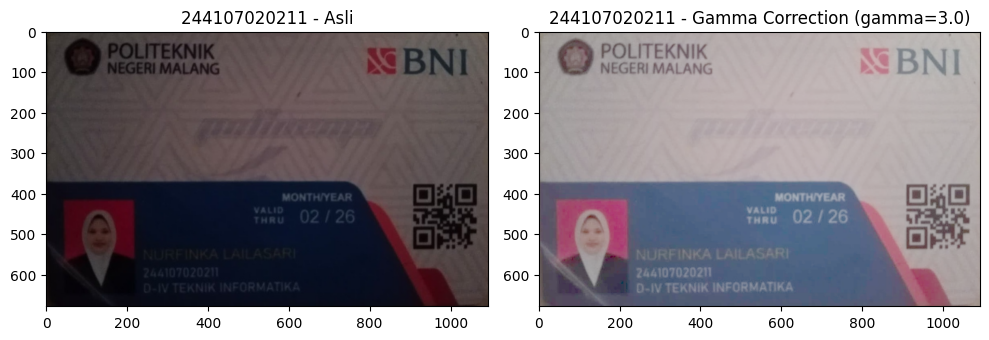

In [12]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = PARAM['gamma']

hasil_gamma = np.zeros(ktm1a.shape, ktm1a.dtype)
for y in range(ktm1a.shape[0]):
    for x in range(ktm1a.shape[1]):
        for c in range(ktm1a.shape[2]):
            nilai = 255 * ((ktm1a[y, x, c] / 255) ** (1 / gamma))
            hasil_gamma[y, x, c] = truncate(nilai)

tampilkan_dua(ktm1a, hasil_gamma, 'Asli', f'Gamma Correction (gamma={gamma})')

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 24.00


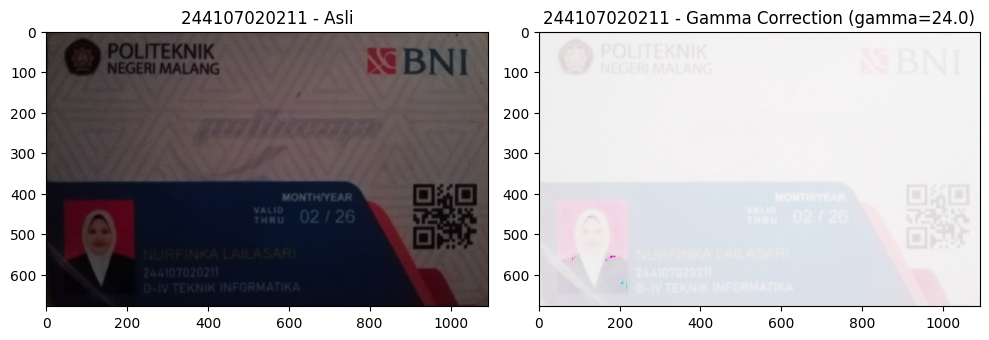

In [21]:
 # Niliai gama dari jumlah nim
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = PARAM['gamma']

hasil_gamma = np.zeros(ktm1a.shape, ktm1a.dtype)
for y in range(ktm1a.shape[0]):
    for x in range(ktm1a.shape[1]):
        for c in range(ktm1a.shape[2]):
            nilai = 255 * ((ktm1a[y, x, c] / 255) ** (1 / gamma))
            hasil_gamma[y, x, c] = truncate(nilai)

tampilkan_dua(ktm1a, hasil_gamma, 'Asli', f'Gamma Correction (gamma={gamma})')

Tampilkan minimal lima nilai gamma yang dicoba beserta hasilnya, sebutkan nilai gamma terbaik pilihan Anda, dan jelaskan
mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama.

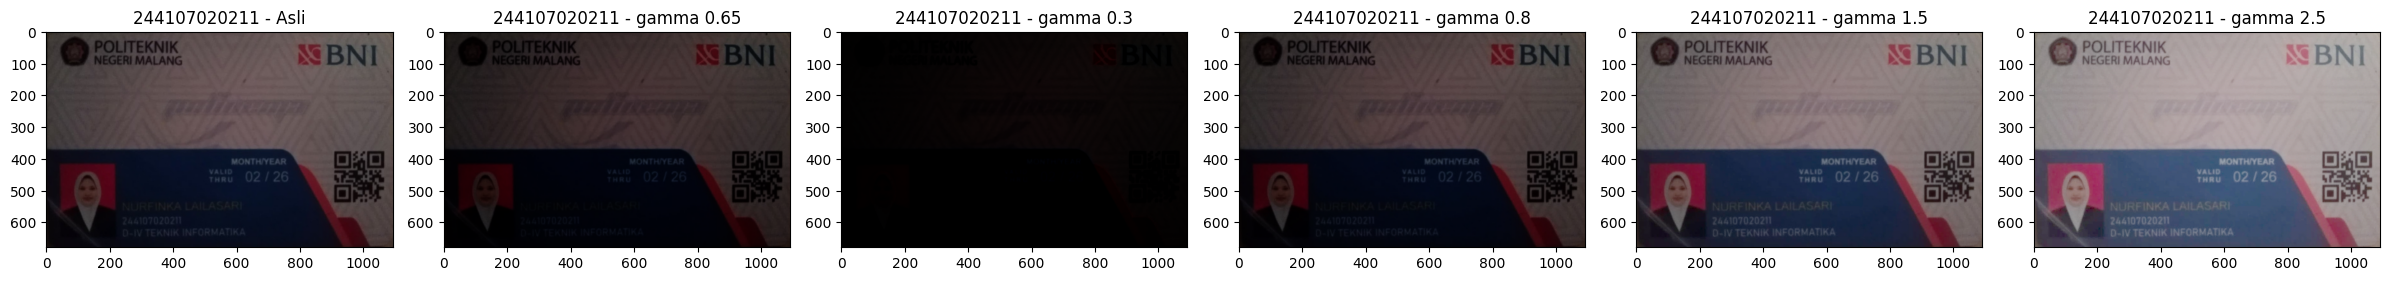

In [13]:
# Fungsi gamma correction, dipakai untuk mencoba beberapa nilai sekaligus
def gamma_correction(img, gamma):
    hasil = np.zeros(img.shape, img.dtype)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            for c in range(img.shape[2]):
                nilai = 255 * ((img[y, x, c] / 255) ** (1 / gamma))
                hasil[y, x, c] = truncate(nilai)
    return hasil

# Coba minimal 5 nilai gamma, mulai dari PARAM['gamma'], cari yang membuat NIM & nama paling terbaca
gamma_list = [PARAM['gamma'], 0.3, 0.8, 1.5, 2.5]  # TODO: sesuaikan/tambahkan nilai yang Anda coba

fig, axs = plt.subplots(1, len(gamma_list) + 1, figsize=(4 * (len(gamma_list) + 1), 4))
axs[0].imshow(cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB)); axs[0].set_title(f'{NIM} - Asli')
for i, g in enumerate(gamma_list):
    hasil = gamma_correction(ktm1a, g)
    axs[i + 1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[i + 1].set_title(f'{NIM} - gamma {g}')
plt.tight_layout(); plt.show()

> Nilai gamma terbaik pilihan saya adalah $\gamma = 1.5$ karena teks nama, NIM, dan detail foto tampak paling jelas serta memiliki kontras yang seimbang tanpa menjadi terlalu gelap seperti pada $\gamma = 0.3$ atau terlalu silau dan memudar seperti pada $\gamma = 2.5$. Nilai terbaik setiap mahasiswa berbeda-beda karena tingkat kegelapan ruangan saat pemotretan tidak sama, karakteristik sensor kamera HP dalam menangkap cahaya bervariasi, serta warna dasar dan kontras tulisan pada masing-masing kartu identitas memiliki perbedaan.

**7. Buat Simulasi Image Depth pada Citra Pribadi**

Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).

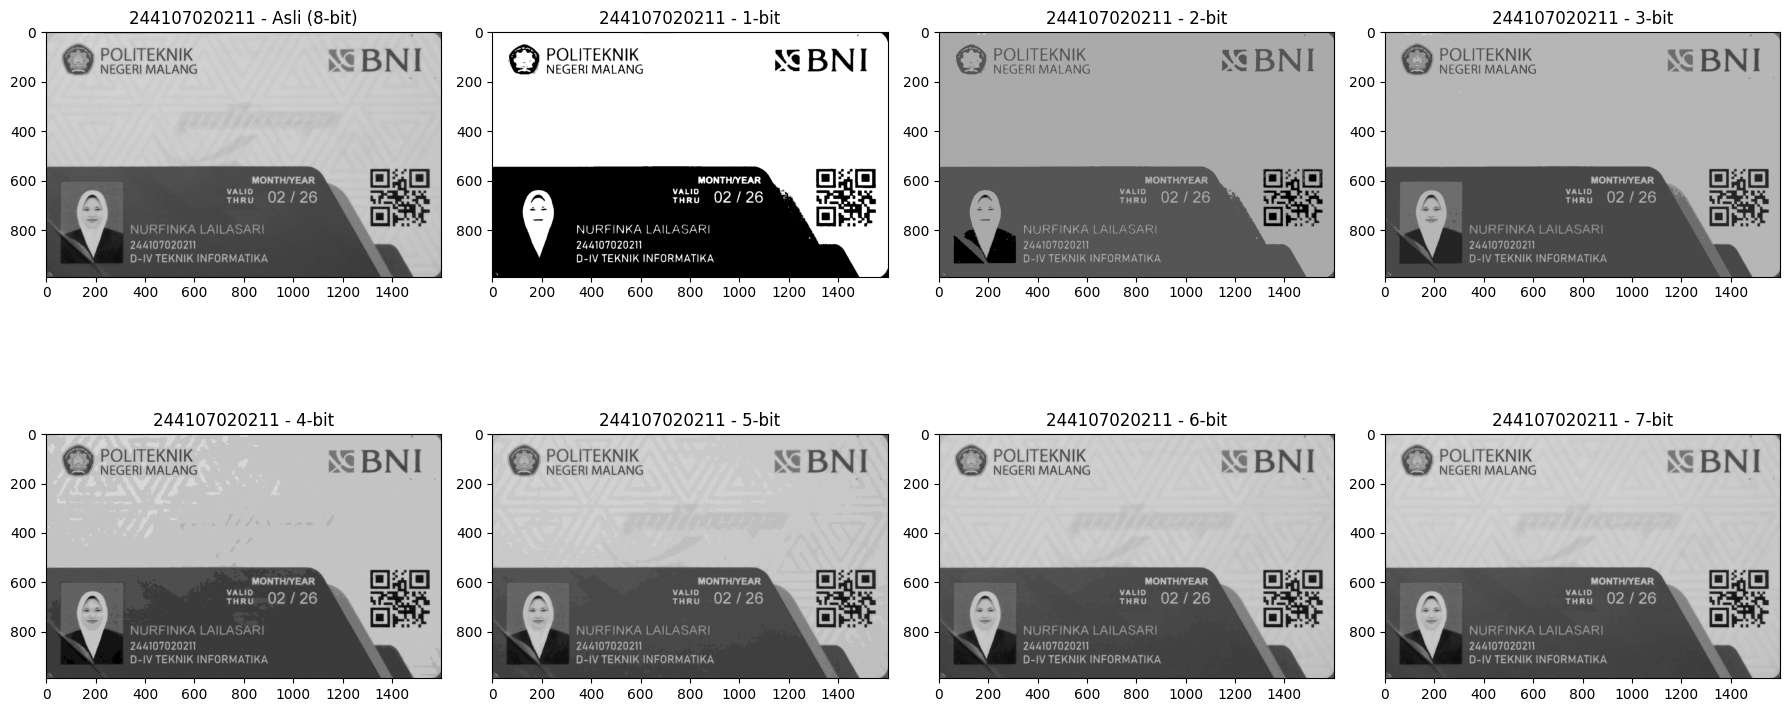

Parameter bit dari NIM (PARAM['bit']) = 3


In [14]:
ktm1b_gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
tinggi, lebar = ktm1b_gray.shape

def simulasi_bit_depth(img, bit_depth):
    level = 255 / (pow(2, bit_depth) - 1)
    hasil = np.zeros(img.shape, img.dtype)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            nilai_baru = round(img[y, x] / level) * level
            hasil[y, x] = truncate(nilai_baru)
    return hasil

fig, axs = plt.subplots(2, 4, figsize=(18, 9))
axs = axs.ravel()
axs[0].imshow(ktm1b_gray, cmap='gray'); axs[0].set_title(f'{NIM} - Asli (8-bit)')
for i, bit_depth in enumerate(range(1, 8)):
    hasil = simulasi_bit_depth(ktm1b_gray, bit_depth)
    axs[i + 1].imshow(hasil, cmap='gray')
    axs[i + 1].set_title(f'{NIM} - {bit_depth}-bit')
plt.tight_layout(); plt.show()

print(f"Parameter bit dari NIM (PARAM['bit']) = {PARAM['bit']}")

> **Analisis**
>
> Berdasarkan hasil pengujian pada gambar yang ditampilkan, teks nama dan NIM pada kartu sudah mulai terbaca sejak kedalaman 1-bit karena teks berwarna putih berada di atas bidang hitam pekat. Namun, detail wajah dan logo instansi mengalami kerusakan parah (false contouring) serta informasi di area terang hilang. Detail wajah dan teks secara keseluruhan mulai tampak wajar dan terbaca stabil tanpa kehilangan elemen visual penting pada kedalaman 3-bit (parameter NIM), serta terlihat sangat jelas mendekati citra asli 8-bit mulai pada kedalaman 4-bit ke atas

**8. Average Denoising**

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab sebelumnya

Isi folder hasil extract: ['noises'] ...
Jumlah citra noise ditemukan: 100


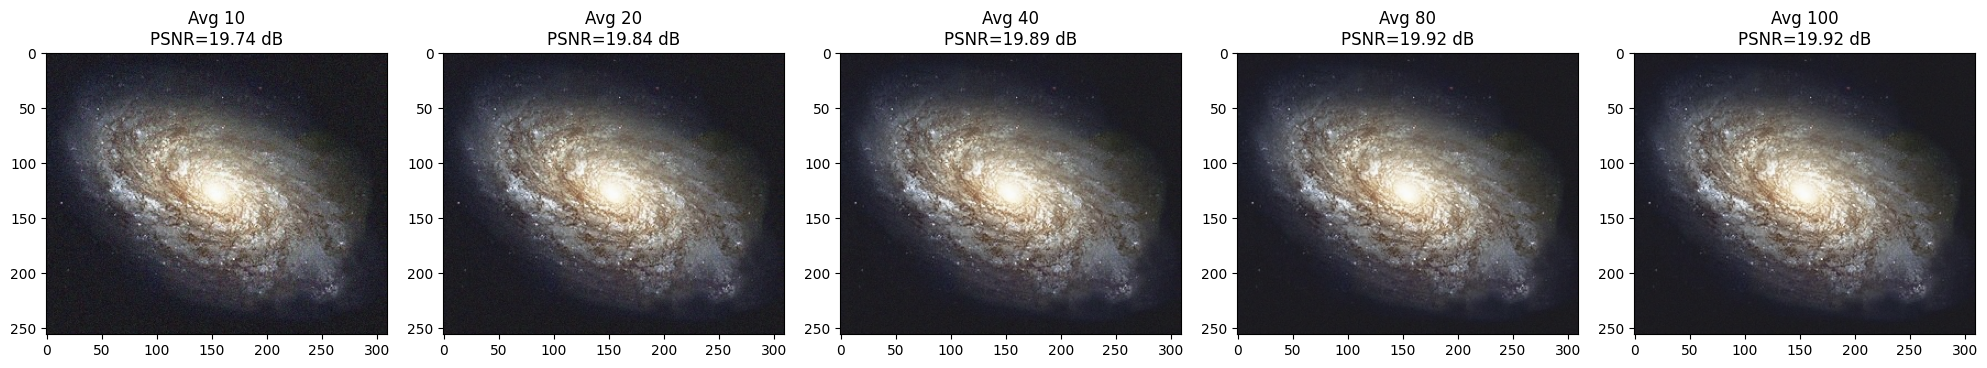

10 citra -> PSNR: 19.74 dB
20 citra -> PSNR: 19.84 dB
40 citra -> PSNR: 19.89 dB
80 citra -> PSNR: 19.92 dB
100 citra -> PSNR: 19.92 dB


In [15]:
import zipfile
import os

BASE_NIM = '/content/drive/MyDrive/PCVK/Images/244107020211'   # folder foto pribadi
DENOISE_BASE = '/content/drive/MyDrive/PCVK/Images'             # folder galaxy.jpg & zip noise

zip_path = DENOISE_BASE + '/noises-image.zip'
extract_path = '/content/noises_extracted'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print('Isi folder hasil extract:', os.listdir(extract_path)[:5], '...')

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

citra_asli = cv.imread(DENOISE_BASE + '/galaxy.jpg')
if citra_asli is None:
    print('GAGAL baca galaxy.jpg, cek path DENOISE_BASE!')

cv_img = []
for img_path in sorted(glob.glob(extract_path + '/**/*.jpg', recursive=True)):
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

print(f'Jumlah citra noise ditemukan: {len(cv_img)}')

def average_denoise(list_img, jumlah):
    stacked = np.stack(list_img[:jumlah], axis=0).astype(np.float64)
    hasil = np.mean(stacked, axis=0)
    return np.clip(hasil, 0, 255).astype(np.uint8)

jumlah_uji = [10, 20, 40, 80, 100]
hasil_psnr = []

fig, axs = plt.subplots(1, len(jumlah_uji), figsize=(4 * len(jumlah_uji), 4))
for i, jumlah in enumerate(jumlah_uji):
    jumlah_efektif = min(jumlah, len(cv_img))
    hasil = average_denoise(cv_img, jumlah_efektif)
    psnr = PSNR(citra_asli, hasil)
    hasil_psnr.append((jumlah, psnr))
    axs[i].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[i].set_title(f'Avg {jumlah}\nPSNR={psnr:.2f} dB')
plt.tight_layout(); plt.show()

for jumlah, psnr in hasil_psnr:
    print(f'{jumlah} citra -> PSNR: {psnr:.2f} dB')

Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
> Tidak


Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
> Titik jenuh: Kenaikan PSNR mulai melandai setelah 40 citra dan menjadi konstan di angka 19.92 dB pada rentang 80 hingga 100 citra.

Apa Kesimpulan yang Anda peroleh dari percobaan ini?
> Kesimpulan: Average denoising efektif menghilangkan derau acak pada penambahan awal, tetapi memiliki batas efisiensi karena di atas 40 citra peningkatan kualitas visual sudah tidak sebanding dengan beban komputasinya.

**9. Buat Image Masking untuk Penyamaran Data Pribadi**

Buat mask biner Anda sendiri yang menutup area foto wajah dan area NIM pada
KTM1d.jpg, lalu gabungkan dengan citra menggunakan operator AND sehingga kedua
area tersebut tersamarkan.

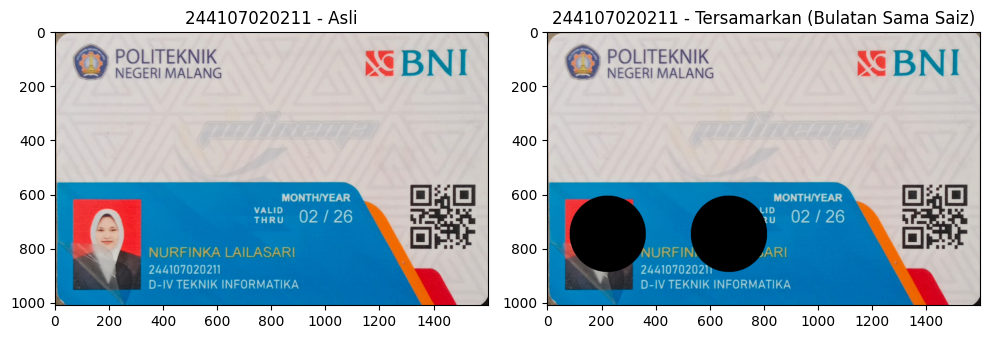

Pusat dan jejari wajah: (224, 747, 141)
Pusat dan jejari NIM  : (672, 747, 141)


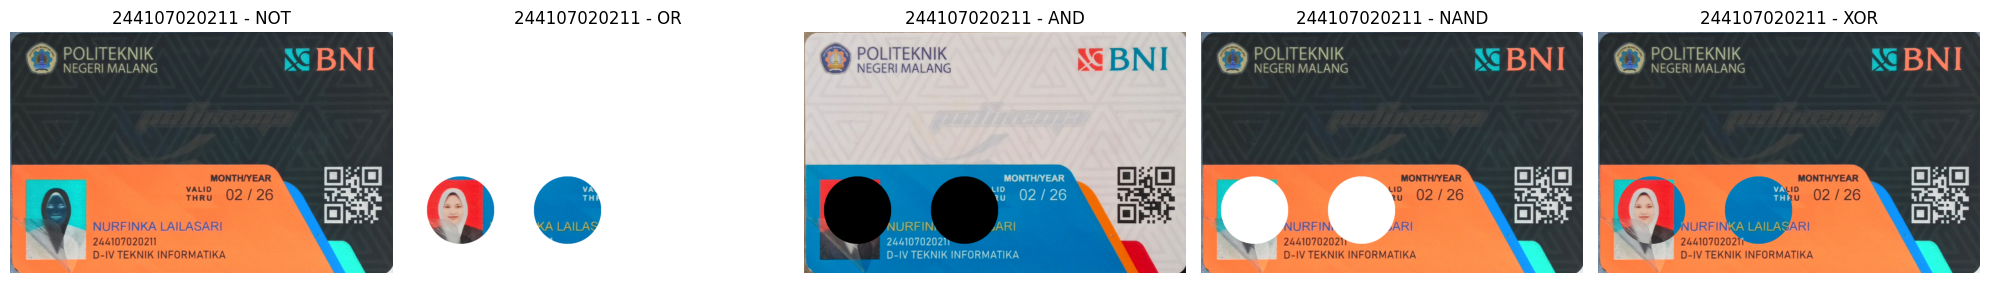

In [24]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

ktm1d = cv.imread(BASE + '/KTM1d.jpg')
tinggi, lebar = ktm1d.shape[:2]
mask = np.full((tinggi, lebar), 255, dtype=np.uint8)
jejari_sama = int(min(lebar, tinggi) * 0.14)

# Titik pusat bulatan (center_x, center_y, radius)
bulatan_wajah = (int(lebar * 0.14), int(tinggi * 0.74), jejari_sama)
bulatan_nim   = (int(lebar * 0.42), int(tinggi * 0.74), jejari_sama)

# Lukis bulatan hitam pekat (nilai 0) pada topeng binari
for (cx, cy, r) in [bulatan_wajah, bulatan_nim]:
    cv.circle(mask, (cx, cy), r, 0, -1)

# Tukar topeng ke 3 saluran (BGR) untuk operasi bitwise
mask_bgr = cv.merge([mask, mask, mask])

# Operasi penyamaran menggunakan bitwise AND mengikut arahan modul
hasil = cv.bitwise_and(ktm1d, mask_bgr)

# Paparkan imej Asal vs Tersamar
cv2_imshow_pair(ktm1d, hasil, 'Asli', 'Tersamarkan (Bulatan Sama Saiz)')
print(f'Pusat dan jejari wajah: {bulatan_wajah}')
print(f'Pusat dan jejari NIM  : {bulatan_nim}')

# Uji kaji pengendali logik bitwise yang lain
op_not  = cv.bitwise_not(ktm1d)
op_or   = cv.bitwise_or(ktm1d, mask_bgr)
op_and  = hasil
op_nand = cv.bitwise_not(op_and)
op_xor  = cv.bitwise_xor(ktm1d, mask_bgr)

hasil_operator = [
    ('NOT', op_not),
    ('OR', op_or),
    ('AND', op_and),
    ('NAND', op_nand),
    ('XOR', op_xor)
]

fig, axs = plt.subplots(1, len(hasil_operator), figsize=(4 * len(hasil_operator), 4))
for i, (nama, hasil_op) in enumerate(hasil_operator):
    axs[i].imshow(cv.cvtColor(hasil_op, cv.COLOR_BGR2RGB))
    axs[i].set_title(f'{NIM} - {nama}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

> ###  **Hasil Analisi**
>* NOT (Komplemen): Membalik seluruh nilai intensitas warna citra asli tanpa memedulikan nilai masker, sehingga menghasilkan citra negatif penuh.
>* OR (Atau): Mengubah seluruh area luar masker bernilai 255 menjadi putih pekat, sementara area bulatan bernilai 0 membiarkan foto dan teks tetap tampil asli (gagal menyamarkan data pribadi).
>* AND (Dan): Menyamarkan data pribadi dengan sempurna karena area bulatan masker bernilai 0 dipaksa menjadi hitam pekat, sedangkan area kartu lainnya yang bernilai 255 tetap tampil utuh.
>* NAND (Not-And):Menghasilkan kebalikan dari operasi AND, di mana bulatan penyamaran berubah menjadi putih terang (255) dan seluruh sisa area kartu menjadi negatif.
>* XOR (Exclusive Or):Hanya membalik warna citra asli menjadi negatif pada area di luar masker (bernilai 255), sedangkan area di dalam bulatan (bernilai 0) tetap mempertahankan tampilan aslinya.
>* Kesimpulan: Operator AND merupakan satu-satunya operator yang tepat dan efektif untuk kebutuhan penyamaran privasi (*privacy masking*).

**10. Foto Malam Hari**

Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik

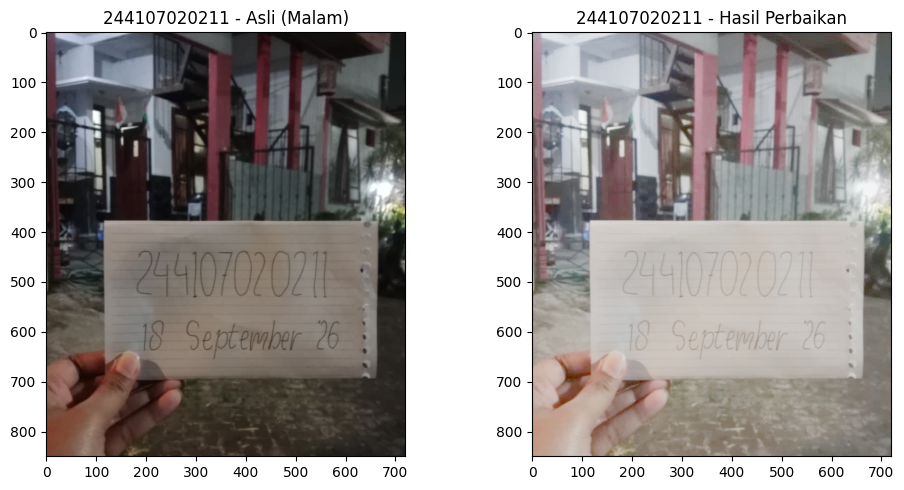

In [17]:
foto_malam = cv.imread(BASE + '/NIGHT1.jpg')

# TODO: pilih metode dan parameter terbaik hasil eksperimen Anda
# Contoh: kombinasi log brightness + gamma correction
c_pilihan = 45        # TODO: sesuaikan konstanta c
hasil_log = log_brightness(foto_malam, c_pilihan)

gamma_pilihan = 0.6    # TODO: sesuaikan nilai gamma
hasil_akhir = gamma_correction(hasil_log, gamma_pilihan)

tampilkan_dua(foto_malam, hasil_akhir, 'Asli (Malam)', 'Hasil Perbaikan')

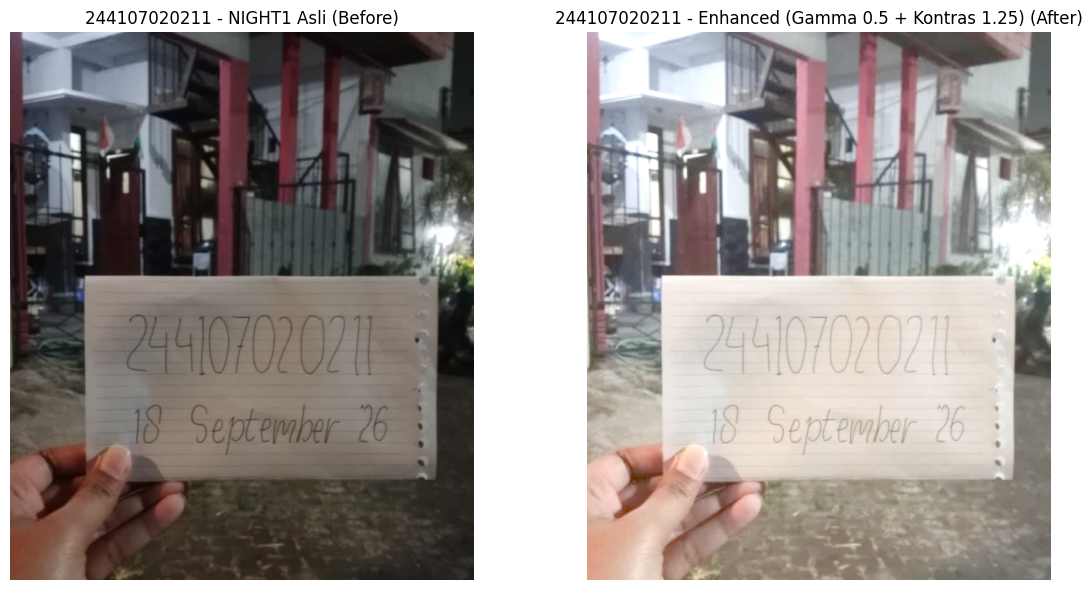

In [25]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img_night = cv.imread(BASE + '/NIGHT1.jpg')

# Gamma Correction untuk mengangkat area bayangan/gelap (gamma < 1)
gamma_val = 0.5
step1 = np.clip(255 * ((img_night / 255.0) ** gamma_val), 0, 255).astype(
    np.uint8 )

# Contrast Enhancement untuk mempertegas batas tepi dan ketajaman teks
alpha = 1.25  # Nilai kontras
result_night = np.clip(alpha * step1.astype(np.float64), 0, 255).astype(np.uint8)

# Tampilkan Before-After
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(img_night, cv.COLOR_BGR2RGB))
axs[0].set_title(f'{NIM} - NIGHT1 Asli (Before)')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(result_night, cv.COLOR_BGR2RGB))
axs[1].set_title(
    f'{NIM} - Enhanced (Gamma {gamma_val} + Kontras {alpha}) (After)'
)
axs[1].axis('off')

plt.tight_layout()
plt.show()

**Metode yang Dipilih**
> Kombinasi metode Gamma Correction ($\gamma = 0.5$) dan Linear Contrast ($a = 1.25$).

**Alasan Pemilihan**
> Koreksi gamma ($\gamma < 1$) mencerahkan latar belakang yang gelap tanpa membuat kertas putih dan lampu menjadi silau (overexposed), sementara kontras mempertegas tulisan tangan NIM dan tanggal agar lebih mudah dibaca.

**Resiko Metode**
> Dapat memperjelas bintik noise/grain kamera pada area gelap dan membuat warna hitam latar memudar menjadi keabuan.

**Penentuan Parameter Terbaik**
> Dengan menggunakan parameter  $\gamma = 0.5$ dan $a = 1.25$ terbukti paling pas karena tulisan tangan terbaca jelas dan detail latar terangkat tanpa menimbulkan efek clipping pada kertas.  